**Set environment**

In [1]:
suppressMessages(suppressWarnings(source("../run_config_project.R")))
suppressMessages(suppressWarnings(library("xgboost")))
suppressMessages(suppressWarnings(library("SHAPforxgboost")))
suppressMessages(suppressWarnings(library("Matrix")))
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319 
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo 
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work 
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data 

You are working with      IGVF BlueSTARR 
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR 
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results 
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts 
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data 
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks 
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs 
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log 
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references 



## Import data

**Import table**

In [2]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_full.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_XY = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 99960   585


Variant_ID,Delta,AC0048:NFE2L/JUN:bZIP,AC0116:THRB/ESRRA:Nuclear_receptor,AC0125:NR1I/VDR:Nuclear_receptor,"AC0158:PAX:Homeodomain,Paired_box",AC0219:ZNF:C2H2_ZF,AC0270:FOXN:Forkhead,AC0272:GMEB:SAND,AC0273:BATF/FOSL:bZIP,AC0449:TIGD:CENPB,AC0495:CTCF/CTCFL:C2H2_ZF,AC0576:ZSCAN/ZNF:C2H2_ZF,AC0629:DBP/HLF:bZIP,AC0631:ATF/CREB:bZIP,AC0634:CREB/JUND:bZIP,AC0688:HSF:HSF,AC0148:BPTF/ZNF:Unknown,AC0162:ZNF:C2H2_ZF,AC0258:NRL/MAFG:bZIP,AC0313:ZBED:BED_ZF,AC0314:ZNF385D:C2H2_ZF,AC0358:ZNF:C2H2_ZF,AC0374:ARID5B:ARID/BRIGHT,AC0460:IRX:Homeodomain,AC0461:ASCL:bHLH,AC0555:NRF:Unknown,AC0597:SMAD:SMAD,AC0070:ZNF:C2H2_ZF,AC0144:ZNF:C2H2_ZF,AC0256:MAFF/MAF:bZIP,AC0271:PROX:Prospero,AC0410:ZNF:C2H2_ZF,AC0476:IRX:Homeodomain,AC0085:ZNF:C2H2_ZF,AC0110:NR2F/NR1H:Nuclear_receptor,AC0238:PBX/PKNOX:Homeodomain,AC0259:MAFG/MAFF:bZIP,AC0362:FOXG/FOXK:Forkhead,AC0584:ZSCAN:C2H2_ZF,AC0603:ZNF:C2H2_ZF,AC0047:ZNF:C2H2_ZF,AC0074:ZBTB/TWIST:C2H2_ZF,AC0077:LYL/OLIG:bHLH,AC0080:ZNF:C2H2_ZF,AC0081:SCRT:C2H2_ZF,AC0149:ZNF:C2H2_ZF,AC0193:ZNF:C2H2_ZF,AC0194:CTCF:C2H2_ZF,AC0450:ZBTB:C2H2_ZF,AC0579:ZNF:C2H2_ZF,AC0587:ZNF:C2H2_ZF,AC0492:TBX/T:T-box,AC0111:NR1H:Nuclear_receptor,AC0161:ZNF:C2H2_ZF,AC0475:TP:p53,AC0485:FOSL:bZIP,AC0599:ZKSCAN:C2H2_ZF,"AC0089:POU4F:Homeodomain,POU","AC0101:POU3F/POU2F:Homeodomain,POU",AC0184:ZNF:C2H2_ZF,"AC0230:POU2F/ZNF:Homeodomain,POU",AC0651:ZNF:C2H2_ZF,AC0039:FOXD/FOXK:Forkhead,AC0268:GMEB:SAND,AC0578:ZNF:C2H2_ZF,AC0628:CEBPB/CEBPE:bZIP,AC0045:ZNF:C2H2_ZF,"AC0076:ERF::FIGLA/ETV2::FIGLA:['Tryptophan_cluster_factors',_'Basic_helix-loop-helix_factors_(bHLH)']",AC0127:TCF7L/LEF:Sox,AC0133:NR6A:Nuclear_receptor,"AC0636:POU5F/NANOG:Homeodomain,POU",AC0124:RARA/RARG:Nuclear_receptor,AC0231:ZNF:C2H2_ZF,AC0233:ZNF:C2H2_ZF,AC0401:ZNF:C2H2_ZF,AC0513:ZNF:C2H2_ZF,AC0559:ZNF:C2H2_ZF,AC0594:ZNF:C2H2_ZF,AC0200:ZNF:C2H2_ZF,AC0202:ZNF:C2H2_ZF,"AC0483:PAX:Homeodomain,Paired_box","AC0484:PAX:Homeodomain,Paired_box",AC0494:ZIC/GLIS:C2H2_ZF,AC0367:ZNF:C2H2_ZF,AC0512:YY:C2H2_ZF,AC0237:ZNF:C2H2_ZF,AC0260:IRX:Homeodomain,AC0481:ZNF:C2H2_ZF,AC0504:ZNF:C2H2_ZF,"AC0515:PAX:Homeodomain,Paired_box",AC0046:BACH/NFE:bZIP,AC0096:PBX/HOXA:Homeodomain,AC0098:MEIS/PBX:Homeodomain,AC0113:RARA/ESRRA:Nuclear_receptor,AC0115:NR1I/NR1H:Nuclear_receptor,AC0551:CENPB:CENPB,AC0568:ZNF:C2H2_ZF,AC0049:JUND/JUN:bZIP,AC0234:ZNF:C2H2_ZF,AC0269:FOXN:Forkhead,AC0366:ZNF:C2H2_ZF,AC0488:TBX:T-box,AC0511:YY/ZFP:C2H2_ZF,AC0192:ZIK:C2H2_ZF,AC0024:POU3F/HESX:Homeodomain,AC0165:ZNF:C2H2_ZF,AC0300:ZNF:C2H2_ZF,AC0118:THRA/THRB:Nuclear_receptor,AC0120:THRB:Nuclear_receptor,AC0122:ESR/ESRRA:Nuclear_receptor,AC0123:NR1D/RORC:Nuclear_receptor,AC0155:ZNF:C2H2_ZF,AC0257:ZNF:C2H2_ZF,AC0289:RFX/MXI:RFX,AC0390:ZFP:C2H2_ZF,AC0666:IRF:IRF,AC0009:DUXA/DUX:Homeodomain,AC0163:NR1D:Nuclear_receptor,AC0502:ZNF:C2H2_ZF,AC0520:ZNF/EGR:C2H2_ZF,AC0581:ZNF:C2H2_ZF,AC0591:ZNF:C2H2_ZF,AC0655:RUNX:Runt,AC0075:MYOD/MYOG:bHLH,AC0182:ZNF:C2H2_ZF,AC0108:RXRG/RARB:Nuclear_receptor,AC0136:NR2E:Nuclear_receptor,AC0222:ZNF/ZFP:C2H2_ZF,AC0507:ZNF:C2H2_ZF,AC0353:ZSCAN:C2H2_ZF,AC0550:GCM:GCM,AC0557:ZNF:C2H2_ZF,AC0196:ZNF:C2H2_ZF,AC0284:DMRT/DMRTA:DM,AC0641:ETV/ETS:Ets,AC0642:SPIB/SPI:Ets,AC0275:MYB/MYBL:Myb/SANT,AC0010:PROP/ALX:Homeodomain,AC0028:ZNF:C2H2_ZF,AC0109:ZNF:C2H2_ZF,AC0505:ZSCAN:C2H2_ZF,AC0589:ZNF:C2H2_ZF,AC0487:TBX/T:T-box,AC0530:ZSCAN/KLF:C2H2_ZF,AC0169:ZNF:C2H2_ZF,AC0396:MYRF:Ndt80/PhoG,AC0549:GCM:GCM,AC0570:ZNF:C2H2_ZF,AC0583:ZNF:C2H2_ZF,AC0595:ZNF:C2H2_ZF,AC0086:MEIS/PKNOX:Homeodomain,AC0459:SIX/ZNF:Homeodomain,AC0025:ZNF:C2H2_ZF,AC0677:BCL11A/IRF:C2H2_ZF,"AC0102:POU2F/POU3F:Homeodomain,POU",AC0180:ZNF:C2H2_ZF,AC0430:ZNF:C2H2_ZF,AC0531:ZNF:C2H2_ZF,AC0019:TLX/PAX:Homeodomain,AC0226:ZNF:C2H2_ZF,AC0413:ZNF:C2H2_ZF,AC0586:ZNF:C2H2_ZF,AC0050:ZSCAN5C:C2H2_ZF,AC0051:BATF/IRF:bZIP,AC0135:NR2E:Nuclear_receptor,AC0468:ZNF:C2H2_ZF,AC0590:ZNF:C2H2_ZF,AC0352:ZNF:C2H2_ZF,AC0387:ZFP:C2H2_ZF,AC0510:YY/MZF:C2H2_ZF,AC0388:ZNF:C2H2_ZF,AC0094:NR1H/WT:Nuclear_receptor,AC0205:ZNF:C2H2_ZF,AC0206:ZNF:C2H2_ZF,AC0302:ZIM:C2H2_ZF,AC042

In [3]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_full_xgb_cv05fold.rds"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
obj = read_rds(txt_fpath)

### assign and show
fit_xgb_cv = obj
print(obj)

##### xgb.cv 5-folds
  iter train_rmse_mean train_rmse_std test_rmse_mean test_rmse_std
 <num>           <num>          <num>          <num>         <num>
     1      0.44082749   3.781942e-05     0.44083034  0.0001671893
     2      0.41884231   3.471953e-05     0.41884907  0.0001667261
     3      0.39795943   3.204200e-05     0.39797047  0.0001662181
     4      0.37812278   2.937342e-05     0.37813884  0.0001659905
     5      0.35928131   2.604784e-05     0.35930257  0.0001659218
   ---             ---            ---            ---           ---
   655      0.01582688   7.609789e-05     0.02132068  0.0006927838
   656      0.01582331   7.698929e-05     0.02132077  0.0006926435
   657      0.01582081   7.782302e-05     0.02132169  0.0006928231
   658      0.01581725   7.863185e-05     0.02132089  0.0006928321
   659      0.01581406   7.839765e-05     0.02132086  0.0006923871
Best iteration:
  iter train_rmse_mean train_rmse_std test_rmse_mean test_rmse_std
 <num>           <num>   

In [4]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_full_xgb_model.rds"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
obj = read_rds(txt_fpath)
obj = xgb.Booster.complete(obj)

### assign and show
fit_xgb_final = obj
print(obj)

##### xgb.Booster
raw: 1.2 Mb 
call:
  xgb.train(params = lst_param, data = dat_train, nrounds = best_nrounds, 
    watchlist = watchlist, verbose = 0)
params (as set within xgb.train):
  booster = "gbtree", objective = "reg:squarederror", eval_metric = "rmse", eta = "0.05", max_depth = "5", subsample = "0.8", colsample_bytree = "0.8", validate_parameters = "TRUE"
xgb.attributes:
  niter
callbacks:
  cb.evaluation.log()
# of features: 583 
niter: 608
nfeatures : 583 
evaluation_log:
  iter train_rmse
 <num>      <num>
     1 0.44082771
     2 0.41884314
   ---        ---
   608 0.01629730
   609 0.01629065


## arrange table

In [5]:
### init: get data for XY
dat = dat_XY

### keep variant ID separately
vec_txt_variant = dat$Variant_ID

### response variable
y = dat$Delta

### feature matrix
X = dat %>% dplyr::select(-Variant_ID, -Delta)

### convert to numeric matrix
X_mat = as.matrix(X)

dat_train = xgb.DMatrix(data = X_mat, label = y)

## Delta

In [7]:
### get the variant and delta (BlueSTARR)
dat = dat_XY
dat = dat %>% dplyr::select(Variant_ID, Delta) %>% dplyr::arrange(desc(Delta))

### assign and show
dat_Y = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 99960     2


Variant_ID,Delta
chr4:74487586:A:G:C,0.9649841
chr9:135685432:G:G:C,0.9454227
chr1:173251490:G:G:C,0.9101272


In [8]:
dat = dat_Y
vec = dat$Variant_ID

vec_txt_variant_sort = vec
print(length(vec))
head(vec, 3)

[1] 99960


[1] "chr4:74487586:A:G:C"  "chr9:135685432:G:G:C" "chr1:173251490:G:G:C"

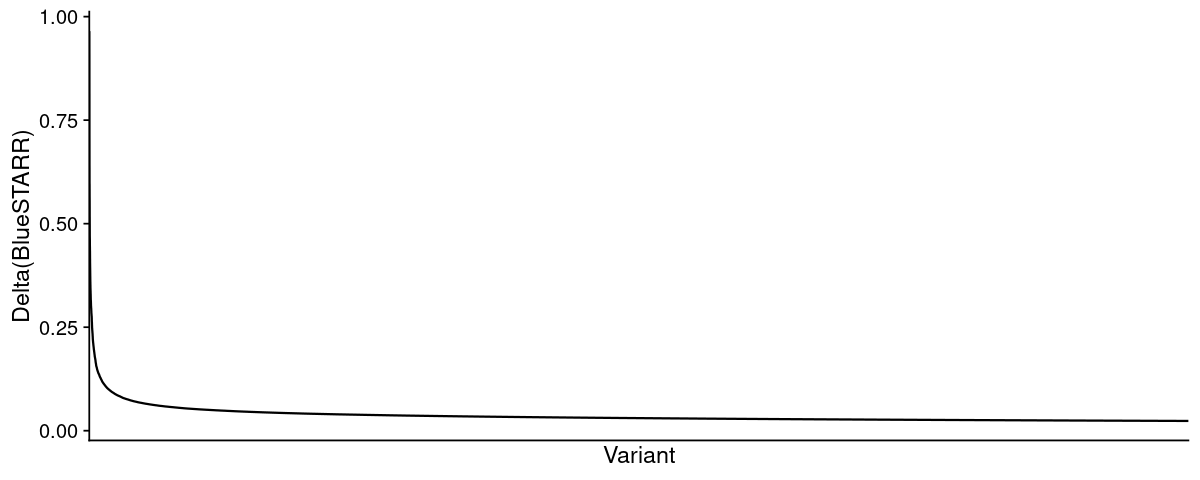

In [11]:
### init
dat = dat_Y

### order variants
dat = dat %>% dplyr::mutate(Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort))

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.text.x  = element_blank() 
)
gpt = ggplot(dat, aes(x=Variant_ID, y = Delta, group=1)) +
    geom_line() +
    theme_cowplot() +
    theme_custom +
    labs(x = "Variant", y = "Delta(BlueSTARR)")

###
gpt_Y = gpt
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

## CV

In [12]:
num_best_iter = fit_xgb_cv$best_iteration
print(num_best_iter)

[1] 609


In [13]:
### get the training log
fit = fit_xgb_cv
dat = fit$evaluation_log

### assign and show
dat_log_cv = dat
print(dim(dat))
fun_display_table(head(dat))

[1] 659   5


iter,train_rmse_mean,train_rmse_std,test_rmse_mean,test_rmse_std
1,0.4408275,3.78e-05,0.4408303,0.0001672
2,0.4188423,3.47e-05,0.4188491,0.0001667
3,0.3979594,3.20e-05,0.3979705,0.0001662
4,0.3781228,2.94e-05,0.3781388,0.0001660
5,0.3592813,2.60e-05,0.3593026,0.0001659
6,0.3413851,2.21e-05,0.3414094,0.0001658


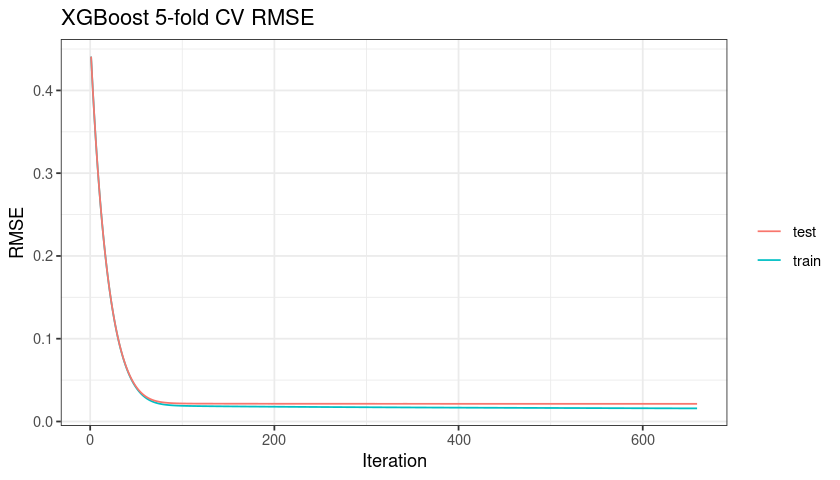

In [14]:
dat = dat_log_cv
gpt = ggplot(dat, aes(x = iter)) +
    geom_line(aes(y = train_rmse_mean, colour = "train")) +
    geom_line(aes(y = test_rmse_mean,  colour = "test")) +
    labs(x = "Iteration",
       y = "RMSE",
       colour = "",
       title = "XGBoost 5-fold CV RMSE") +
  theme_bw()

options(repr.plot.height = 4, repr.plot.width = 7)
print(gpt)

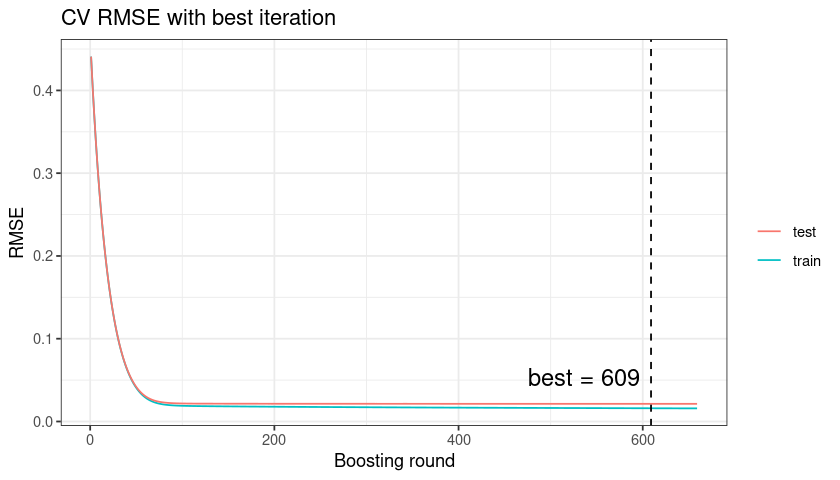

In [17]:
dat = dat_log_cv
gpt = ggplot(dat, aes(x = iter)) +
  geom_line(aes(y = train_rmse_mean, colour = "train")) +
  geom_line(aes(y = test_rmse_mean,  colour = "test")) +
  geom_vline(xintercept = num_best_iter, linetype = 2) +
  annotate(
      "text", 
      x = num_best_iter, 
      y = min(dat$test_rmse_mean),
      label = paste("best =", num_best_iter), 
      vjust = -1, 
      hjust =  1.1,
      size  = 5) +
  labs(x = "Boosting round", 
       y = "RMSE", 
       colour = "",
       title = "CV RMSE with best iteration") +
  theme_bw()

options(repr.plot.height = 4, repr.plot.width = 7)
print(gpt)

## Final model

In [22]:
class(fit_xgb_final)

[1] "xgb.Booster"

In [24]:
fit$evaluation_log

NULL

In [14]:
### get the training log
fit = fit_xgb_final
dat = fit$evaluation_log

### assign and show
dat_log_final = dat
print(dim(dat))
fun_display_table(head(dat))

[1] 609   2


iter,train_rmse
1,0.4408277
2,0.4188431
3,0.3979593
4,0.3781216
5,0.3592764
6,0.3413817


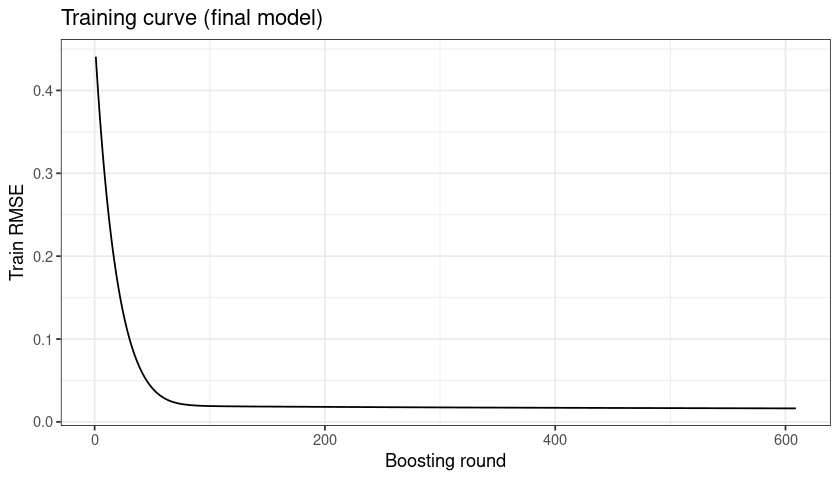

In [15]:
dat = dat_log_final
gpt = ggplot(dat, aes(x = iter, y = train_rmse)) +
  geom_line() +
  labs(x = "Boosting round",
       y = "Train RMSE",
       title = "Training curve (final model)") +
  theme_bw()

options(repr.plot.height = 4, repr.plot.width = 7)
print(gpt)

In [ ]:
imp_xgb = xgb.importance(
  model = fit_xgb_final,
  feature_names = colnames(X_mat)
)

xgb.plot.importance(imp_xgb[1:30, ])  # top 30 motifs

```
Predicted vs observed

Residuals vs predicted

Histogram of residuals

Feature importance

SHAP beeswarm plot

SHAP dependence plot for top motifs
```

## Basic diagnostics: predicted vs observed, residuals

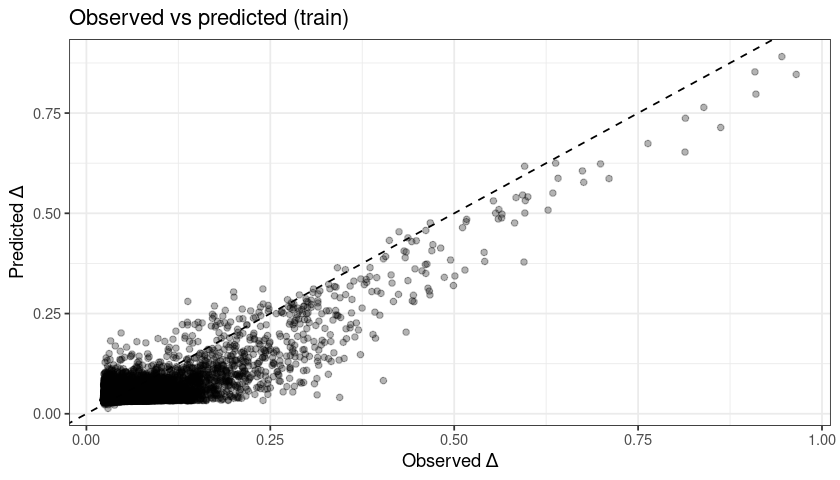

In [20]:
y_true  = y
y_pred  = predict(fit_xgb_final, dat_train)
dat_diag = data.frame(y_true = y_true, y_pred = y_pred)

ggplot(dat_diag, aes(x = y_true, y = y_pred)) +
  geom_point(alpha = 0.3) +
  geom_abline(slope = 1, intercept = 0, linetype = 2) +
  labs(x = "Observed Δ",
       y = "Predicted Δ",
       title = "Observed vs predicted (train)") +
  theme_bw()

In [21]:
dat_diag$resid = dat_diag$y_true - dat_diag$y_pred

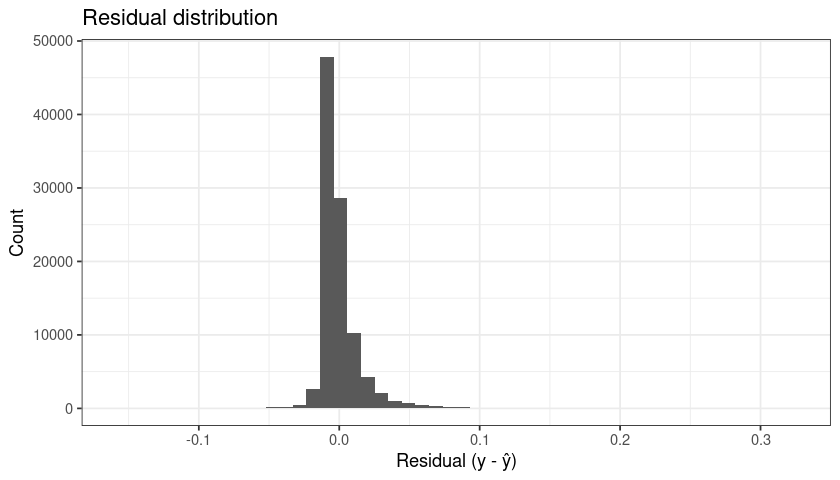

In [22]:
# Histogram
ggplot(dat_diag, aes(x = resid)) +
  geom_histogram(bins = 50) +
  labs(x = "Residual (y - ŷ)",
       y = "Count",
       title = "Residual distribution") +
  theme_bw()

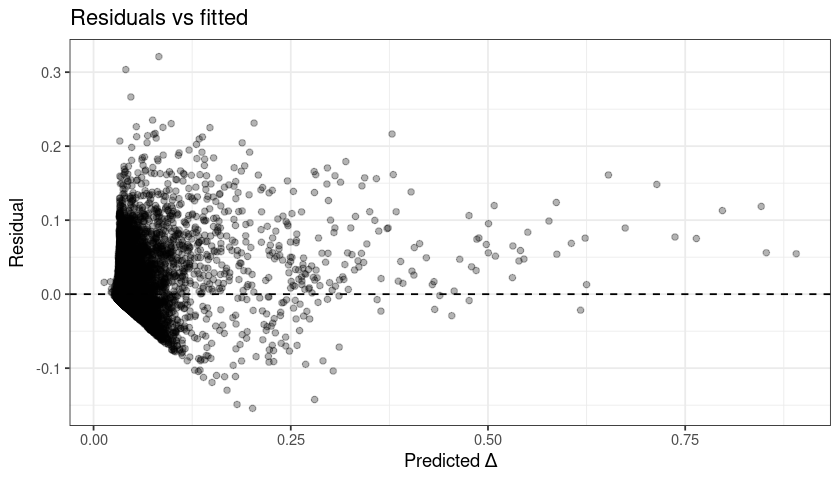

In [23]:
# Residual vs fitted
ggplot(dat_diag, aes(x = y_pred, y = resid)) +
  geom_point(alpha = 0.3) +
  geom_hline(yintercept = 0, linetype = 2) +
  labs(x = "Predicted Δ",
       y = "Residual",
       title = "Residuals vs fitted") +
  theme_bw()

## Feature importance & SHAP plots

### XGBoost feature importance
This is a classic “overall importance” view (not as nuanced as SHAP, but easy to sanity check).

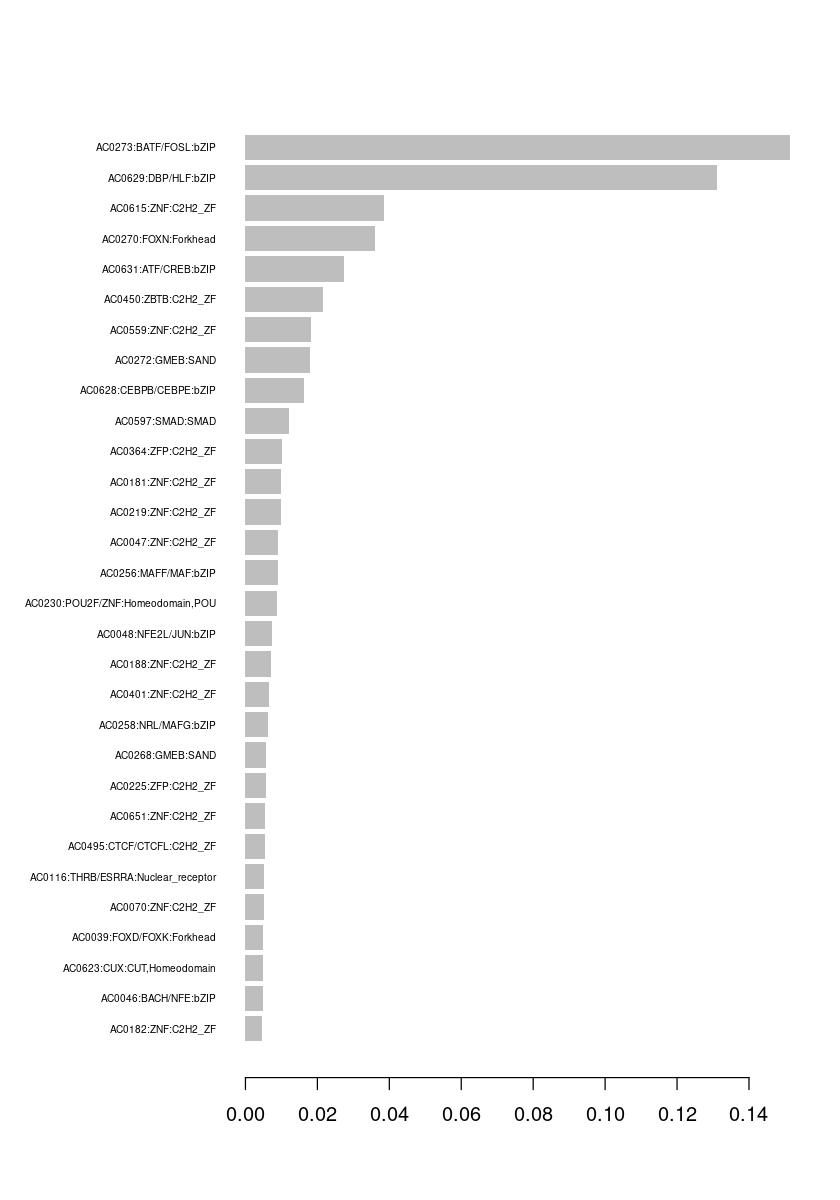

In [25]:
imp_xgb = xgb.importance(
  model = fit_xgb_final,
  feature_names = colnames(X_mat)
)
options(repr.plot.height = 10, repr.plot.width = 7)
xgb.plot.importance(imp_xgb[1:30, ])  # top 30 motifs

### SHAP summary plot
Global SHAP summary (per-feature importance + distribution):

In [ ]:
shap.plot.summary(
  shap_contrib = lst_shap_value$shap_score,
  X = X_mat
)

```
# SHAPforxgboost already designed shap.plot.summary() mainly for matrix,
# but you can also use dat_shap_long_arrange directly:

shap.plot.summary.dat(dat_shap_long_arrange)
# (this helper exists in newer versions; if not, stick to shap_contrib + X)
```

## SHAP dependence plot for specific motifs

Pick a motif, for example “AC0629:DBP/HLF:bZIP”:

In [ ]:
otif_name = "AC0629:DBP/HLF:bZIP"

shap.plot.dependence(
  xgb_model   = fit_xgb_final,
  X_train     = X_mat,
  shap_contrib = lst_shap_value$shap_score,
  x           = motif_name
)

Or for two-way interactions (e.g., DBP vs AP-1 motif):

In [ ]:
shap.plot.dependence(
  xgb_model   = fit_xgb_final,
  X_train     = X_mat,
  shap_contrib = lst_shap_value$shap_score,
  x           = "AC0629:DBP/HLF:bZIP",
  y           = "MA0099.4 FOS::JUN"
)

A complete diagnostics code block

including all the following plots:

Predicted vs observed scatter with R²

Residual histogram

Residual vs predicted

Feature importance (gain, cover, weight)

SHAP summary beeswarm

SHAP dependence plot for top k motifs

Below is a complete, ready-to-run diagnostic script for your XGBoost gain-only model.
It includes:

Loading the model (+ restoring pointer)

Loading X_mat, y, Variant_ID

Predicted vs Observed

Residual analysis

Feature importance plots

SHAP values (summary + top motifs)

Optional: save all plots

I structured it so you can cleanly paste into an R notebook or script.m

✔ Predicted vs observed

Shows model correlation with ground truth.

✔ Residuals vs predicted

Shows if variance is unequal, or systematic bias.

✔ Histogram of residuals

Shows distribution & outliers.

✔ Feature importance

Top motifs by XGBoost Gain.

✔ SHAP summary plot

Your real motif-level importance across all variants.

✔ SHAP dependence plot for the top motif

Shows how motif strength influences Δ.

In [ ]:
suppressMessages(library(tidyverse))
suppressMessages(library(xgboost))
suppressMessages(library(SHAPforxgboost))
suppressMessages(library(ggplot2))

###------------------------------------------------------------
### 1. Load Model + Restore Pointer
###------------------------------------------------------------

txt_fdiry = file.path(
    FD_RES,
    "analysis_variant_motif_richard",
    "motifdelta_pilot_jvierstra_v2.0beta"
)

txt_fpath_model = file.path(
    txt_fdiry,
    "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_full_xgb_model.rds"
)

fit_xgb_final = read_rds(txt_fpath_model)
fit_xgb_final = xgb.Booster.complete(fit_xgb_final)
print(fit_xgb_final)


###------------------------------------------------------------
### 2. Load Data (needed for diagnostics)
###------------------------------------------------------------

txt_fpath_XY = file.path(
    txt_fdiry,
    "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_full.tsv"
)

dat_XY = read_tsv(txt_fpath_XY, show_col_types = FALSE)

y  = dat_XY$Delta
X  = dat_XY %>% dplyr::select(-Variant_ID, -Delta)
X_mat = as.matrix(X)
variant_ids = dat_XY$Variant_ID


###------------------------------------------------------------
### 3. Predictions & Residuals
###------------------------------------------------------------

pred = predict(fit_xgb_final, X_mat)
res  = y - pred

df_eval = tibble(
    Variant_ID = variant_ids,
    Observed   = y,
    Predicted  = pred,
    Residual   = res
)

###------------------------------------------------------------
### 4. Plot: Predicted vs Observed
###------------------------------------------------------------

g_pred_vs_obs = ggplot(df_eval, aes(x = Observed, y = Predicted)) +
    geom_point(alpha = 0.3, size = 0.8) +
    geom_abline(slope = 1, intercept = 0, color = "red") +
    labs(
        title = "Predicted vs Observed Δ",
        x = "Observed Δ",
        y = "Predicted Δ"
    ) +
    theme_bw()

print(g_pred_vs_obs)


###------------------------------------------------------------
### 5. Plot: Residuals vs Predicted
###------------------------------------------------------------

g_res_vs_pred = ggplot(df_eval, aes(x = Predicted, y = Residual)) +
    geom_point(alpha = 0.3, size = 0.8) +
    geom_hline(yintercept = 0, color = "red") +
    labs(
        title = "Residuals vs Predicted",
        x = "Predicted Δ",
        y = "Residual"
    ) +
    theme_bw()

print(g_res_vs_pred)


###------------------------------------------------------------
### 6. Plot: Histogram of Residuals
###------------------------------------------------------------

g_hist_res = ggplot(df_eval, aes(x = Residual)) +
    geom_histogram(bins = 60, fill = "steelblue", alpha = 0.7) +
    labs(
        title = "Histogram of Residuals",
        x = "Residual",
        y = "Count"
    ) +
    theme_bw()

print(g_hist_res)


###------------------------------------------------------------
### 7. Feature Importance (Gain / Cover / Frequency)
###------------------------------------------------------------

imp = xgb.importance(model = fit_xgb_final)

g_imp_gain = xgb.plot.importance(imp, top_n = 30, measure = "Gain") +
    ggtitle("Top 30 Features by Gain")

print(g_imp_gain)

### Other measures:
# xgb.plot.importance(imp, top_n = 30, measure = "Cover")
# xgb.plot.importance(imp, top_n = 30, measure = "Frequency")


###------------------------------------------------------------
### 8. SHAP Values
###------------------------------------------------------------

shap_res = shap.values(xgb_model = fit_xgb_final, X_train = X_mat)
shap_long = shap.prep(
    shap_contrib = shap_res$shap_score,
    X_train      = X_mat
)

# Add Variant ID
shap_long = shap_long %>% mutate(Variant_ID = variant_ids[ID])

### SHAP summary (beeswarm)
g_shap_summary = shap.plot.summary(shap_long)
print(g_shap_summary)


###------------------------------------------------------------
### 9. SHAP Dependence Plot (Top Motif)
###------------------------------------------------------------

top_motif = shap_res$mean_shap_score %>%
    sort(decreasing = TRUE) %>%
    names() %>%
    .[1]  # the top motif name

cat("Top motif:", top_motif, "\n")

g_shap_dependence = shap.plot.dependence(
    data_long = shap_long,
    x = top_motif,
    color_feature = top_motif
)

print(g_shap_dependence)


###------------------------------------------------------------
### 10. (Optional) SAVE the plots
###------------------------------------------------------------

# ggsave("pred_vs_obs.png", g_pred_vs_obs, width = 6, height = 5)
# ggsave("residuals_vs_pred.png", g_res_vs_pred, width = 6, height = 5)
# ggsave("hist_residuals.png", g_hist_res, width = 6, height = 5)
# ggsave("shap_summary.png", g_shap_summary, width = 7, height = 6)
# ggsave("shap_dependence_top1.png", g_shap_dependence, width = 6, height = 5)


here is a clean, publication-ready figure panel that combines your most important diagnostics into one unified layout suitable for a manuscript, talk, or thesis.

The panel includes:

A. Cross-validation curve (train/test RMSE)
B. Predicted vs Observed (Δ)
C. Feature Importance (Gain)
D. SHAP Summary (beeswarm)

This gives a complete picture of:

model generalization

accuracy

motif-level contributions

In [ ]:
suppressMessages(library(tidyverse))
suppressMessages(library(ggplot2))
suppressMessages(library(ggpubr))
suppressMessages(library(xgboost))
suppressMessages(library(SHAPforxgboost))

###------------------------------------------------------------
### 0. Load model and data
###------------------------------------------------------------

dir_base <- file.path(
    FD_RES,
    "analysis_variant_motif_richard",
    "motifdelta_pilot_jvierstra_v2.0beta"
)

# Load best model (RDS so evaluation_log is available)
fit <- readRDS(file.path(
    dir_base,
    "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_full_xgb_model.rds"
))
fit <- xgb.Booster.complete(fit)

# Load XY table
dat_XY <- read_tsv(
    file.path(dir_base, "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_full.tsv"),
    show_col_types = FALSE
)

# Prepare matrices
y  <- dat_XY$Delta
X  <- dat_XY %>% select(-Variant_ID, -Delta)
X_mat <- as.matrix(X)
variant_ids <- dat_XY$Variant_ID


###------------------------------------------------------------
### A. Cross-validation curve
###------------------------------------------------------------

# Load CV object
fit_cv <- readRDS(file.path(
    dir_base,
    "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_full_xgb_cv05fold.rds"
))

num_best <- fit_cv$best_iteration
dat_cv <- fit_cv$evaluation_log

g_cv <- ggplot(dat_cv, aes(x = iter)) +
    geom_line(aes(y = train_rmse_mean, color = "Train")) +
    geom_line(aes(y = test_rmse_mean,  color = "Test")) +
    geom_vline(xintercept = num_best, linetype = 2) +
    annotate("text",
             x = num_best,
             y = min(dat_cv$test_rmse_mean),
             label = paste("best =", num_best),
             hjust = -0.1, vjust = -1) +
    scale_color_manual(values = c("Train" = "steelblue", "Test" = "firebrick")) +
    labs(title = "A. Cross-validation RMSE",
         x = "Iteration",
         y = "RMSE",
         color = "") +
    theme_bw() +
    theme(legend.position = "top")


###------------------------------------------------------------
### B. Predicted vs Observed
###------------------------------------------------------------

pred <- predict(fit, X_mat)
df_eval <- tibble(Observed = y, Predicted = pred)

g_pred <- ggplot(df_eval, aes(x = Observed, y = Predicted)) +
    geom_point(alpha = 0.3, size = 0.8) +
    geom_abline(slope = 1, intercept = 0, color = "red") +
    labs(title = "B. Predicted vs Observed Δ",
         x = "Observed Δ",
         y = "Predicted Δ") +
    theme_bw()


###------------------------------------------------------------
### C. Feature Importance (top 20 by Gain)
###------------------------------------------------------------

imp <- xgb.importance(model = fit)
imp_top20 <- imp %>% slice_head(n = 20)

g_imp <- xgb.plot.importance(imp_top20, measure = "Gain") +
    ggtitle("C. Top 20 Motifs by XGBoost Gain") +
    theme_bw() +
    theme(axis.text.y = element_text(size = 7))


###------------------------------------------------------------
### D. SHAP summary plot (beeswarm)
###------------------------------------------------------------

shap_res <- shap.values(xgb_model = fit, X_train = X_mat)
shap_long <- shap.prep(
    shap_contrib = shap_res$shap_score,
    X_train      = X_mat
)

g_shap <- shap.plot.summary(shap_long) +
    ggtitle("D. SHAP Summary (Motif Contributions)")


###------------------------------------------------------------
### Combine into a 2x2 panel
###------------------------------------------------------------

panel <- ggarrange(
    g_cv, g_pred, g_imp, g_shap,
    labels = NULL,
    ncol = 2, nrow = 2,
    heights = c(1, 1.2)
)

print(panel)


###------------------------------------------------------------
### Optionally save as PDF
###------------------------------------------------------------
# ggsave(file.path(dir_base, "figure_panel_xgb_diagnostics.pdf"),
#        panel, width = 14, height = 12)
